In [1]:
import pandas as pd
import numpy as np

In [2]:
from scripts.plots import plot_density 
from scripts.plots import plot_cross_correlation
from scripts.plots import plot_percentage_change
from scripts.stat_functions import check_normality
from scripts.functions import z_normalization
from scripts.functions import shift_column_in_dataset
from scripts.functions import correlation_and_p_value

# The Impact of US Oil Price on the Grocery Basket in Different Continents

This study analyses the impact of US oil price on the grocery breakfast basket. We chose to study the monthly average cost of the breakfast basket in different continents and analyze whether those price data is correlated with the US oil price for the same period.

 We will use a multi-source grocery price dataset tracking 14 food staples across 122 cities in 80 countries, with a 6-month time series (October 2025 – March 2026). Breakfast basket includes the total price for milk, bread, eggs and rice per city.

The daily prices of US Oil fund are downloaded from Yahoo Finance for the same period.

Historically, increases in oil prices have consistently been linked to higher grocery costs, as modern food systems are heavily dependent on fossil fuels for production, processing, and transportation. 

We will answer the following questions:

    (1): Do oil and grocery costs move in the same direction, i.e., an increase of oil prices results in higher grocery costs and a decrease in oil prices results in lower grocery costs? 

    (2): What is the lagging effect in short term?

    (3): Does the grocery basket increase/decrease with the similar percentage with US oil fund?

The raw data has been transformed to our needs. The grocery dataset is tracking monthly average cost of the breakfast basket in different continents and the finance dataset is tracking monthly average cost of US oil fund.

Merge the transformed grocery and finance datasets.

In [3]:
# load data

breakfast_basket_data = pd.read_csv("data/processed/grocery_preprocessing.csv", index_col = 0)
breakfast_basket_data

,Africa,Asia,Europe,North America,Oceania,South America
Month,,,,,,
2025-10,6.45,7.92,9.93,14.52,12.71,7.97
2025-11,6.57,8.03,10.05,14.67,12.85,8.10
2025-12,6.65,8.12,10.19,15.00,13.12,8.23
2026-01,6.66,8.07,10.09,14.82,12.91,8.15
2026-02,6.82,8.23,10.27,15.08,13.15,8.28
2026-03,6.83,8.23,10.25,15.05,13.12,8.30


In [4]:
# load data

USO_data = pd.read_csv("data/processed/finance_preprocessing.csv", index_col = 0)
USO_data

,USO
Date,
2025-10,71.12
2025-11,70.96
2025-12,69.48
2026-01,72.64
2026-02,78.54
2026-03,108.33


Compare the indexes of the two datasets.

In [5]:
(breakfast_basket_data.index == USO_data.index)

array([ True,  True,  True,  True,  True,  True])

The indexes are equal, we could merge the datasets.

In [6]:
final_data = pd.concat([breakfast_basket_data, USO_data], axis = 1)
final_data

,Africa,Asia,Europe,North America,Oceania,South America,USO
2025-10,6.45,7.92,9.93,14.52,12.71,7.97,71.12
2025-11,6.57,8.03,10.05,14.67,12.85,8.10,70.96
2025-12,6.65,8.12,10.19,15.00,13.12,8.23,69.48
2026-01,6.66,8.07,10.09,14.82,12.91,8.15,72.64
2026-02,6.82,8.23,10.27,15.08,13.15,8.28,78.54
2026-03,6.83,8.23,10.25,15.05,13.12,8.30,108.33


The "final_data" dataset shows the average monthly prices of breakfast grocery basket in different continents and average monthly prices of US oil fund.

We will calculate Pearson correlation coefficient and p-value for testing non-correlation. 

Non-normal data could shift the correlation coefficient, so first we will check if all colummns are normally distributed.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

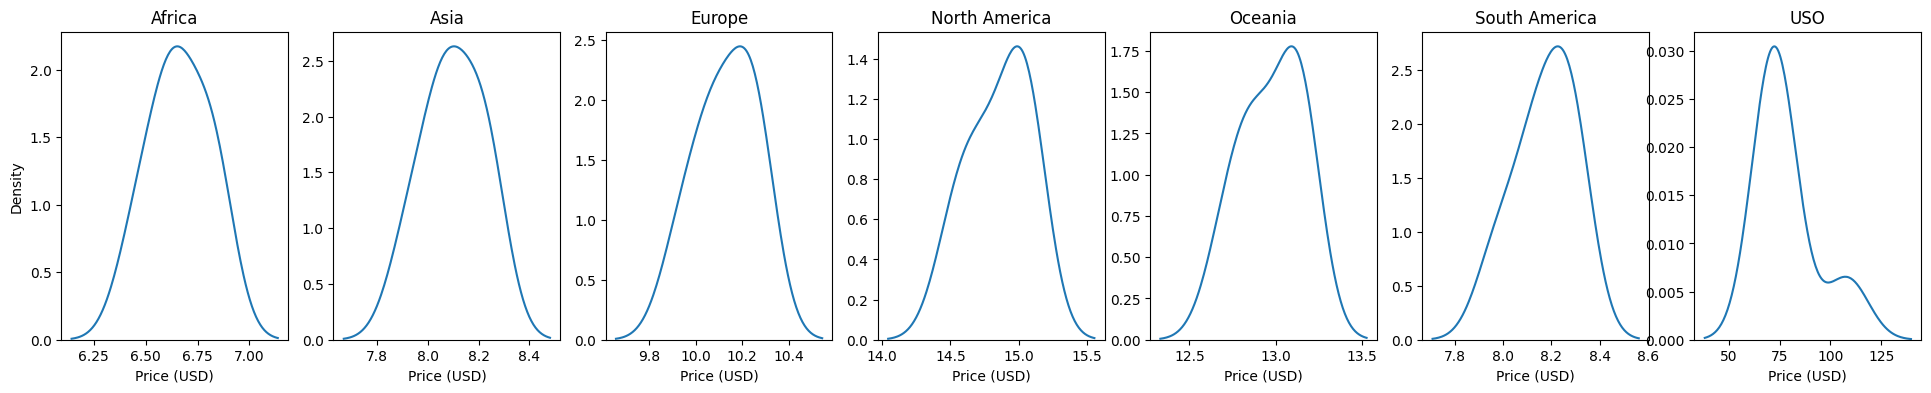

In [8]:
plot_density(final_data)

We see that USO distribution is not normal, but we couldn't be sure for the distribution of the continents from the plots.

We will calculate the distributions by Kolmogorov-Smirnov test for normality:

Null Hypothesis : The sample follows a specified distribution.

Alternative Hypothesis: The sample does not follow the specified distribution.

In [9]:
# check normality for each column
check_normality(final_data)

Africa - p-value: 0.0000
Reject the null hypothesis: The sample does NOT follow the normal distribution.
Asia - p-value: 0.0000
Reject the null hypothesis: The sample does NOT follow the normal distribution.
Europe - p-value: 0.0000
Reject the null hypothesis: The sample does NOT follow the normal distribution.
North America - p-value: 0.0000
Reject the null hypothesis: The sample does NOT follow the normal distribution.
Oceania - p-value: 0.0000
Reject the null hypothesis: The sample does NOT follow the normal distribution.
South America - p-value: 0.0000
Reject the null hypothesis: The sample does NOT follow the normal distribution.
USO - p-value: 0.0000
Reject the null hypothesis: The sample does NOT follow the normal distribution.


All p-values are less than alpha /0 < 0.05/, so we could reject the null hypothesis and conclude that no one of the columns has normal distribution.

Try to normalize data.

Use standard normalization techique and check the normality.

A z-score can be calculated using the following Z- score formula:

z = (X - μ) / σ, 

where:

z = Z-Score

X = Value 

μ = Population Mean

σ = Population Standard Deviation 

In [10]:
# apply z-normalization
final_data_z = final_data.copy()
final_data_z = z_normalization(final_data_z)
final_data_z

,Africa,Asia,Europe,North America,Oceania,South America,USO
0,-1.599500,-1.638622,-1.674437,-1.625653,-1.619221,-1.770058,-0.541778
1,-0.699781,-0.637242,-0.669775,-0.901352,-0.769130,-0.629029,-0.553505
2,-0.099969,0.182069,0.502331,0.692109,0.870331,0.512000,-0.661983
3,-0.024992,-0.273104,-0.334887,-0.177051,-0.404805,-0.190172,-0.430368
4,1.174633,1.183449,1.172106,1.078403,1.052494,0.950858,0.002077
5,1.249610,1.183449,1.004662,0.933543,0.870331,1.126401,2.185558


In [11]:
# check normality for each column
check_normality(final_data_z)

Africa - p-value: 0.8984
Fail to reject the null hypothesis: The sample follows the normal distribution.
Asia - p-value: 0.8934
Fail to reject the null hypothesis: The sample follows the normal distribution.
Europe - p-value: 0.9484
Fail to reject the null hypothesis: The sample follows the normal distribution.
North America - p-value: 0.7466
Fail to reject the null hypothesis: The sample follows the normal distribution.
Oceania - p-value: 0.5216
Fail to reject the null hypothesis: The sample follows the normal distribution.
South America - p-value: 0.9416
Fail to reject the null hypothesis: The sample follows the normal distribution.
USO - p-value: 0.4239
Fail to reject the null hypothesis: The sample follows the normal distribution.


All p-values are greater than alpha /0.05/, so we fail to reject the null hypothesis and conclude that all of the columns has normal distribution.

We will use "final_data_z" dataset for testing correlation between grocery and oil prices.

In [12]:
# all continents names
continents = ["Africa", "Asia",	"Europe", "North America", "Oceania", "South America"]

# oil column
oil = "USO"

Compute cross correlation with shift periods 0-3 months. 

If the correlation is high at these lags, it suggests that movements in USO are predictive of future movements in grocery basket price.

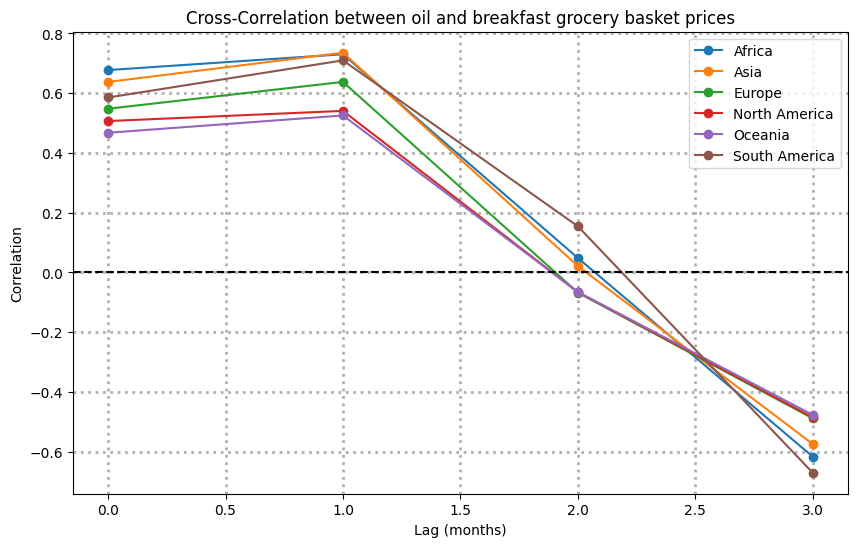

In [13]:
plot_cross_correlation(final_data_z, continents)

Conclusion: the highest correlation is presented at lag 1 month for all continents, so we could suggest that the changes in grocery prices are fact one month after the changes in oil price.

To answer question (2): The lag in short term is one month.

We are studying the change in the prices, so we will create a table with the percentage change.

In [14]:
final_data.pct_change()

,Africa,Asia,Europe,North America,Oceania,South America,USO
2025-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11,0.018605,0.013889,0.012085,0.010331,0.011015,0.016311,-0.002250
2025-12,0.012177,0.011208,0.013930,0.022495,0.021012,0.016049,-0.020857
2026-01,0.001504,-0.006158,-0.009814,-0.012000,-0.016006,-0.009721,0.045481
2026-02,0.024024,0.019827,0.017839,0.017544,0.018590,0.015951,0.081222
2026-03,0.001466,0.000000,-0.001947,-0.001989,-0.002281,0.002415,0.379297


In [15]:
# present as percentage, rounded to 2 decimals

final_data_pct = (final_data.pct_change() * 100).round(2)
final_data_pct

,Africa,Asia,Europe,North America,Oceania,South America,USO
2025-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11,1.86,1.39,1.21,1.03,1.10,1.63,-0.22
2025-12,1.22,1.12,1.39,2.25,2.10,1.60,-2.09
2026-01,0.15,-0.62,-0.98,-1.20,-1.60,-0.97,4.55
2026-02,2.40,1.98,1.78,1.75,1.86,1.60,8.12
2026-03,0.15,0.00,-0.19,-0.20,-0.23,0.24,37.93


In [16]:
# drop nan values
final_data_pct.dropna(inplace = True)
final_data_pct

,Africa,Asia,Europe,North America,Oceania,South America,USO
2025-11,1.86,1.39,1.21,1.03,1.10,1.63,-0.22
2025-12,1.22,1.12,1.39,2.25,2.10,1.60,-2.09
2026-01,0.15,-0.62,-0.98,-1.20,-1.60,-0.97,4.55
2026-02,2.40,1.98,1.78,1.75,1.86,1.60,8.12
2026-03,0.15,0.00,-0.19,-0.20,-0.23,0.24,37.93


The lag period is one month, so we will shift the values in USO column with one month.

In [17]:
shift_column_in_dataset(final_data_pct, oil, 1)
final_data_pct

,Africa,Asia,Europe,North America,Oceania,South America,USO
2025-12,1.22,1.12,1.39,2.25,2.10,1.60,-0.22
2026-01,0.15,-0.62,-0.98,-1.20,-1.60,-0.97,-2.09
2026-02,2.40,1.98,1.78,1.75,1.86,1.60,4.55
2026-03,0.15,0.00,-0.19,-0.20,-0.23,0.24,8.12


We will visualize percentage change.

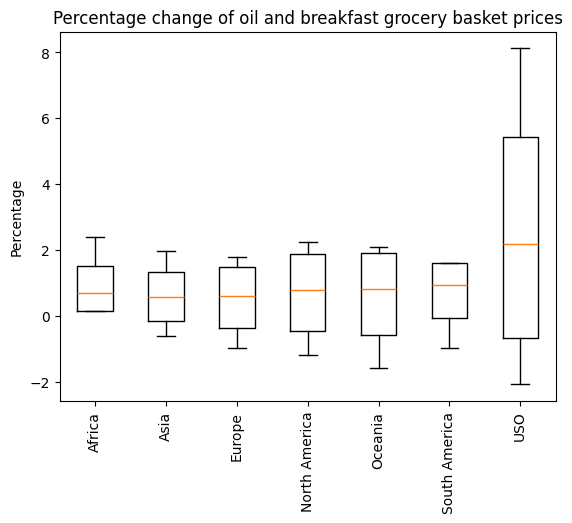

In [18]:
plot_percentage_change(final_data_pct)

Conclusion: While the changes are similar across all continents, it seems that oil prices are changing by a larger percentage range. 

To answer question (3): No, oil prices are chnaging by a larger percentage range than the breakfast grocery prices.

We will calculate Pearson correlation coefficient and p-value for testing non-correlation.

The Pearson correlation coefficient will measure the linear relationship between the oil and the grocery prices in each continent.

P-value will show if the result is statistically significant.

We choose alpha value = 0.05 /5%/.

H0 - no association between the prices.

H1 - linear associasion between the prices.

We could reject H0 if p-value < alpha value.

Interpretation of Pearson correlation coefficient:

+/- 0.8 to 1.0: High/strong correlation.

+/- 0.4 to 0.8: Moderate correlation.

+/- 0.0 to 0.4 : Low/weak correlation.

0: No linear relationship

First we will shift USO prices by one month.

In [19]:
shift_column_in_dataset(final_data_z, oil, 1)
final_data_z

,Africa,Asia,Europe,North America,Oceania,South America,USO
1,-0.699781,-0.637242,-0.669775,-0.901352,-0.769130,-0.629029,-0.541778
2,-0.099969,0.182069,0.502331,0.692109,0.870331,0.512000,-0.553505
3,-0.024992,-0.273104,-0.334887,-0.177051,-0.404805,-0.190172,-0.661983
4,1.174633,1.183449,1.172106,1.078403,1.052494,0.950858,-0.430368
5,1.249610,1.183449,1.004662,0.933543,0.870331,1.126401,0.002077


Calculate Pearson correlation coefficient and p-value for testing non-correlation.

Africa: correlation coefficient = 0.73, p-value = 0.16
Asia: correlation coefficient = 0.74, p-value = 0.16
Europe: correlation coefficient = 0.64, p-value = 0.25
North America: correlation coefficient = 0.54, p-value = 0.35
Oceania: correlation coefficient = 0.53, p-value = 0.36
South America: correlation coefficient = 0.71, p-value = 0.18


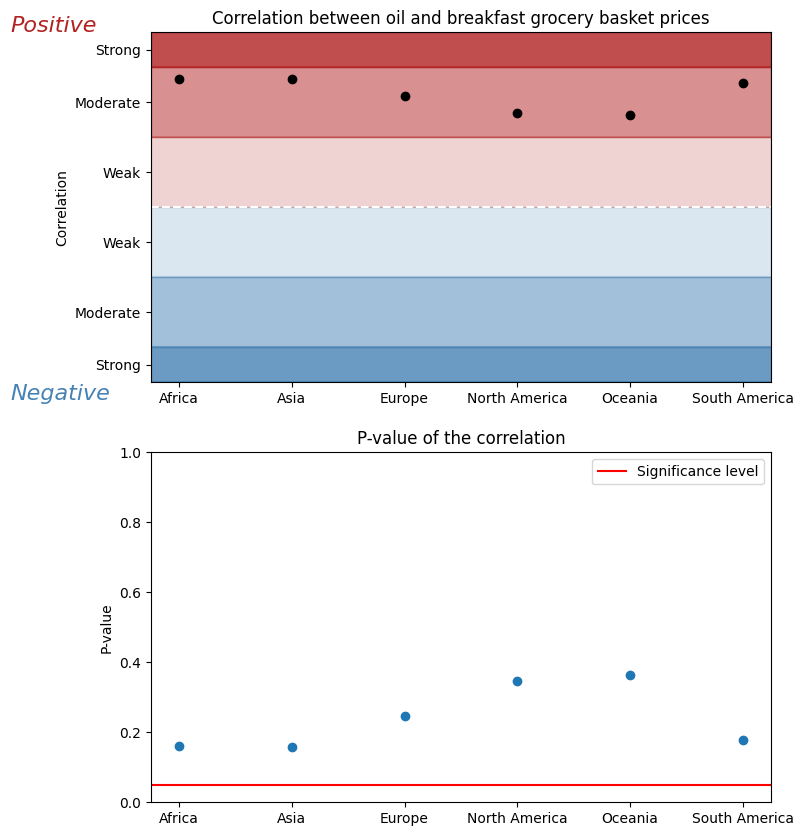

In [20]:
correlation_and_p_value(final_data_z, continents, oil)


Conclusion: There is a moderate positive correlation and a p-value greater than the significant level. This means that we can't reject the null hypothesis and can't conclude that grocery prices and oil prices have a linear correlation.

To answer question (1): Moving of oil and grocery prices in the same direction is not statistically significant and might be due to chance.

This research establishes the comparison between the historical data of oil price and breakfast basket prices in each continent, tracking with a 6-month time series and finds that we have no enough evidence to conclude that there is direct correlation between oil and grocery prices in short term.